In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    recall_score,
    f1_score
)

In [45]:
df = pd.read_csv("credit.csv")

In [46]:
df.head()

,observation_id,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,...,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job,gender
0,0,-43.0,6,critical,radio/tv,1169,NaN,13 years,4,single,...,67,none,own,2,0,1,2.349340e+09,yes,skilled employee,male
1,1,75.0,48,repaid,radio/tv,5951,89.0,2 years,2,NaN,...,22,none,own,1,1,1,NaN,yes,skilled employee,female
2,2,NaN,12,critical,education,2096,24.0,5 years,2,single,...,49,none,own,1,0,2,NaN,yes,unskilled resident,male
3,3,-32.0,42,repaid,furniture,7882,9.0,5 years,2,single,...,45,none,for free,1,0,2,NaN,yes,skilled employee,male
4,4,-23.0,24,delayed,car (new),4870,43.0,3 years,3,single,...,53,none,for free,2,1,2,NaN,yes,skilled employee,male


In [47]:
#Dataset Overview

In [48]:
df.shape

(1000, 23)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   observation_id        1000 non-null   int64  
 1   checking_balance      606 non-null    float64
 2   months_loan_duration  1000 non-null   int64  
 3   credit_history        1000 non-null   object 
 4   purpose               1000 non-null   object 
 5   amount                1000 non-null   int64  
 6   savings_balance       817 non-null    float64
 7   employment_length     938 non-null    object 
 8   installment_rate      1000 non-null   int64  
 9   personal_status       690 non-null    object 
 10  other_debtors         1000 non-null   object 
 11  residence_history     870 non-null    object 
 12  property              1000 non-null   object 
 13  age                   1000 non-null   int64  
 14  installment_plan      1000 non-null   object 
 15  housing               

In [50]:
df.describe()

,observation_id,checking_balance,months_loan_duration,amount,savings_balance,installment_rate,age,existing_credits,default,dependents,telephone
count,1000.000000,606.000000,1000.000000,1000.000000,817.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,4.040000e+02
mean,499.500000,97.245875,20.903000,3271.258000,781.570379,2.973000,35.546000,1.407000,0.300000,1.155000,2.344914e+09
std,288.819436,206.923583,12.058814,2822.736876,3016.983785,1.118715,11.375469,0.577654,0.458487,0.362086,3.008193e+06
min,0.000000,-50.000000,4.000000,250.000000,0.000000,1.000000,19.000000,1.000000,0.000000,1.000000,2.340000e+09
25%,249.750000,-23.000000,12.000000,1365.500000,31.000000,2.000000,27.000000,1.000000,0.000000,1.000000,2.342211e+09
50%,499.500000,24.000000,18.000000,2319.500000,64.000000,3.000000,33.000000,1.000000,0.000000,1.000000,2.344804e+09
75%,749.250000,131.750000,24.000000,3972.250000,128.000000,4.000000,42.000000,2.000000,1.000000,1.000000,2.347731e+09
max,999.000000,999.000000,72.000000,18424.000000,19972.000000,4.000000,75.000000,4.000000,1.000000,2.000000,2.349994e+09


In [51]:
df['default'].value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [52]:
#Exploratory Data Analysis (EDA)

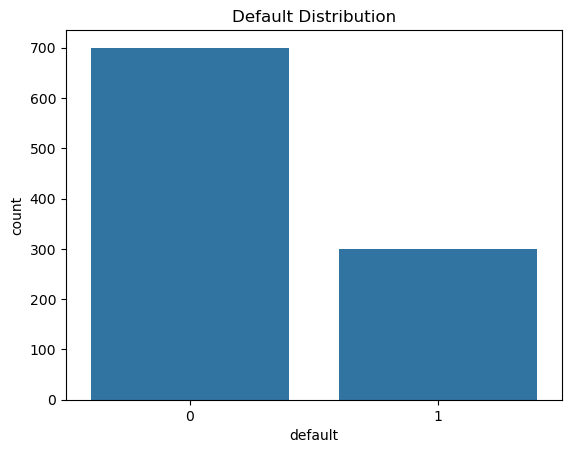

In [53]:
#Target Distribution

sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

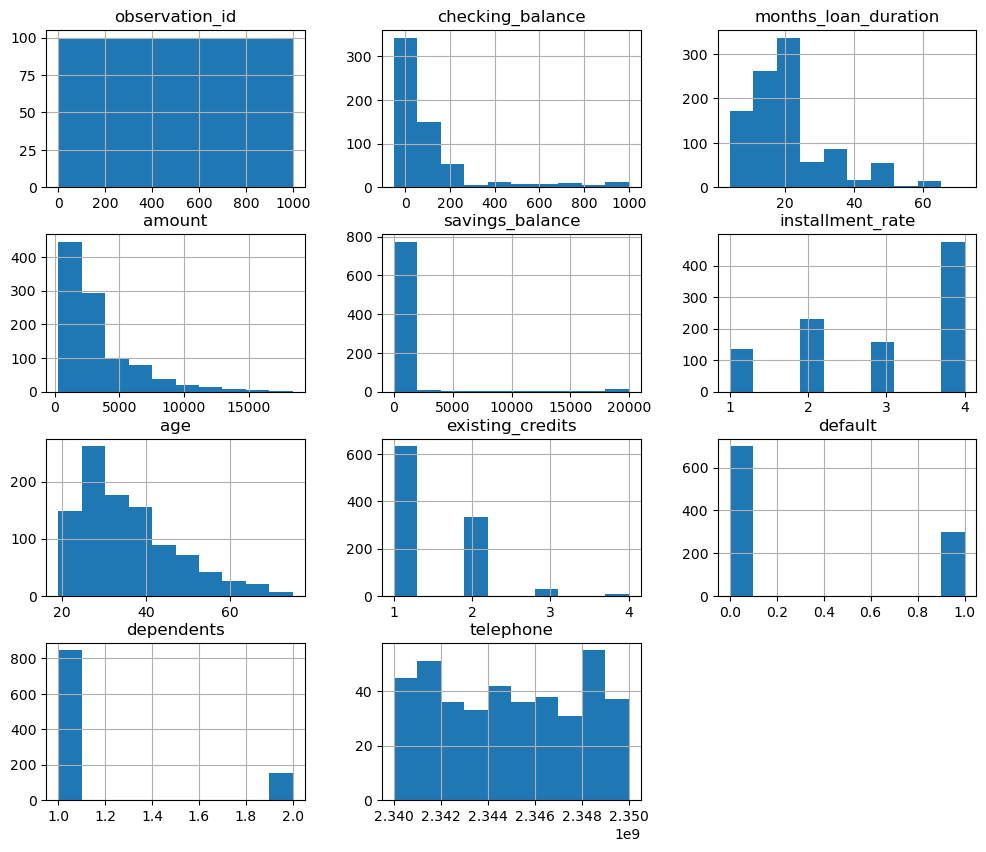

In [54]:
#Numerical Features

df.hist(figsize=(12,10))
plt.show()

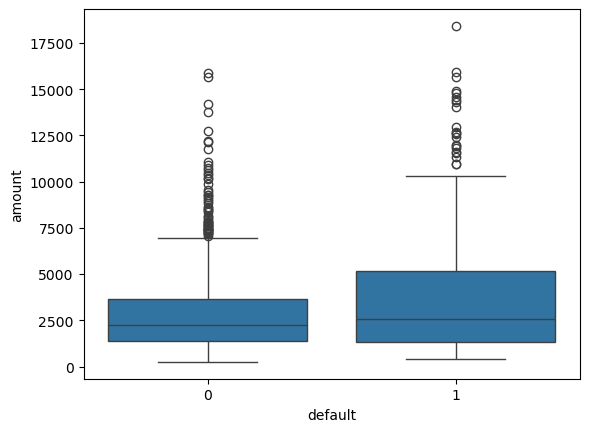

In [55]:
#Example Relationship

sns.boxplot(x='default', y='amount', data=df)
plt.show()

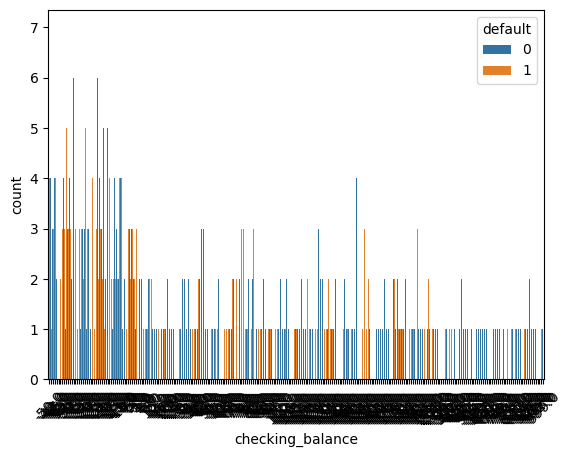

In [56]:
sns.countplot(x='checking_balance', hue='default', data=df)
plt.xticks(rotation=45)
plt.show()

In [57]:
#Data Preprocessing

In [58]:
df = df.drop(columns=["observation_id", "telephone"])

X = df.drop("default", axis=1)
y = df["default"]

In [59]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [60]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=19, stratify=y
)

In [62]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=19))
])

In [63]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

In [65]:
print(y_pred[:10])
print(y_prob[:10])

[1 0 1 1 0 0 1 0 0 1]
[0.78766051 0.26104936 0.72291067 0.79083693 0.01171761 0.08611648
 0.85104754 0.20995576 0.13527403 0.66054456]


In [66]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[126  14]
 [ 36  24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.83       140
           1       0.63      0.40      0.49        60

    accuracy                           0.75       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.73      0.75      0.73       200

ROC-AUC Score: 0.7204761904761905


In [67]:
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=19))
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=19))
])

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=19))
])

In [68]:
dt_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
svm_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       140
           1       0.52      0.53      0.53        60

    accuracy                           0.71       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.72      0.71      0.72       200

ROC-AUC: 0.663095238095238


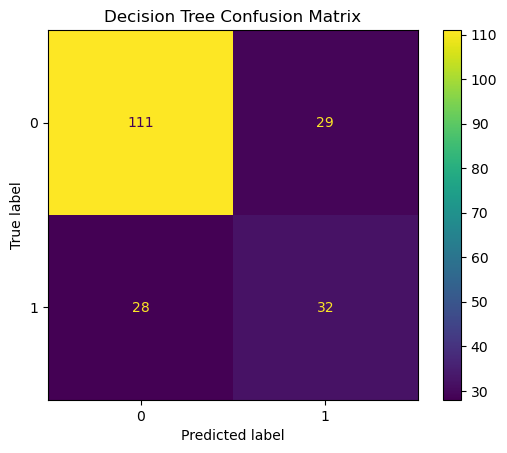


Random Forest
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       140
           1       0.81      0.35      0.49        60

    accuracy                           0.78       200
   macro avg       0.79      0.66      0.67       200
weighted avg       0.79      0.78      0.75       200

ROC-AUC: 0.7758333333333334


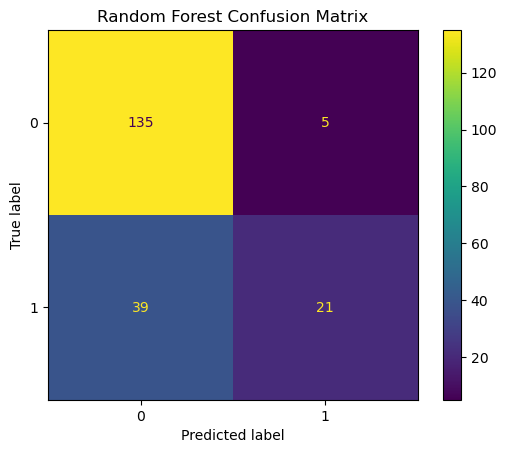


SVM
              precision    recall  f1-score   support

           0       0.77      0.96      0.85       140
           1       0.79      0.32      0.45        60

    accuracy                           0.77       200
   macro avg       0.78      0.64      0.65       200
weighted avg       0.77      0.77      0.73       200

ROC-AUC: 0.7180952380952381


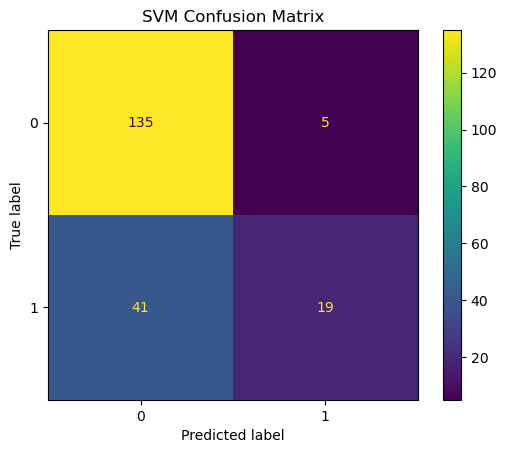

In [72]:
# ---------------- Decision Tree ----------------
print("Decision Tree")
print(classification_report(y_test, dt_pred))
print("ROC-AUC:", roc_auc_score(y_test, dt_prob))

cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


# ---------------- Random Forest ----------------
print("\nRandom Forest")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


# ---------------- SVM ----------------
print("\nSVM")
print(classification_report(y_test, svm_pred))
print("ROC-AUC:", roc_auc_score(y_test, svm_prob))

cm_svm = confusion_matrix(y_test, svm_pred)
ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

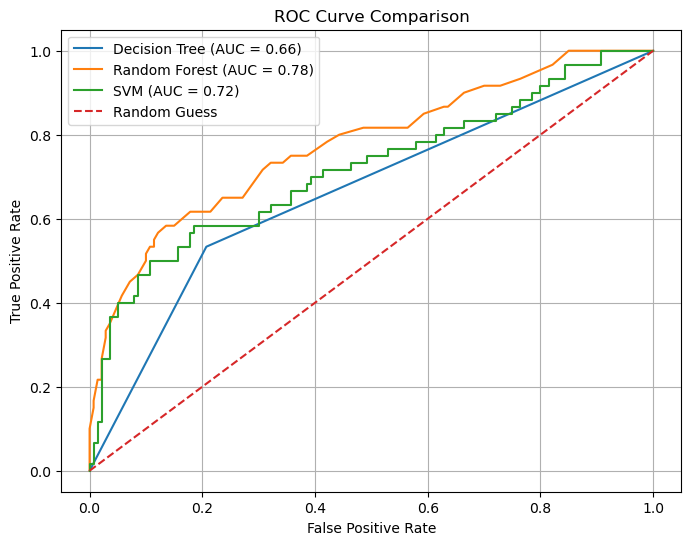

In [73]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Decision Tree ROC
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
dt_auc = auc(dt_fpr, dt_tpr)

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# SVM ROC
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
svm_auc = auc(svm_fpr, svm_tpr)

# Plot all ROC curves
plt.figure(figsize=(8, 6))

plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [74]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results.sort_values(by="Accuracy", ascending=False))

           Model  Accuracy
1  Random Forest     0.780
2            SVM     0.770
0  Decision Tree     0.715


In [75]:
#Among all evaluated models, Random Forest achieved the highest accuracy and demonstrated strong overall performance on the test data. 
#It also maintained a good balance between precision and recall, making it a reliable model for this classification task. 
#Additionally, Random Forest showed competitive ROC-AUC performance, indicating strong ability to distinguish between classes. 
#Due to its ensemble nature, it captures complex patterns better than individual models like Decision Tree. 
#Therefore, Random Forest is selected as the final model for this credit risk problem.